# Introduction to Time Series as Supervised Learning

In this course we mostly work with "standard" supervised learning data:
we have examples in the form of $(X, y)$, where

- $X$ is a matrix with rows as samples and columns as features;
- $y$ is a vector with the corresponding target values.

Important assumption there: **rows are (approximately) independent and exchangeable**.  
The order of the rows in $X$ usually does not matter.

With a **time series**, this is different:

- We have a sequence with a natural order in time: $y_1, y_2, \dots, y_T$.
- Examples: daily temperature, hourly sales, website visits per day, etc.
- Observations that are close in time are often more similar than observations far apart in time.

If we want to treat time series forecasting as a supervised learning problem,
we need to turn the time series into a regular $(X, y)$ dataset.  
We do this using **lags** and a **sliding window**.

Goals of this mini-tutorial:

1. Explain time series vs. standard $(X, y)$ data.
2. Show how to use lags + a sliding window to obtain $(X, y)$.
3. Give a simple example with one series and one exogenous variable.
4. Show how to do a temporal train/validation/test split.
5. Briefly discuss **cross-validation** for time series.
6. Train, validate and test a simple end-to-end model on this data.
7. Baseline model.

## 1. Time Series vs. Standard $(X, y)$ Data

### Standard supervised learning

- We have a dataset with $n$ examples.
- Each example has a feature vector $x^{(i)}$ and a target $y^{(i)}$.
- The order of the examples is usually arbitrary and not important.
- We often split with something like `train_test_split(..., shuffle=True)`.

### Time series

- Observations are ordered in time: index $t = 1, 2, \ldots, T$.
- The target at time $t$, $y_t$, often strongly depends on previous values $y_{t-1}, y_{t-2}, \dots$.
- The order of the data is essential.
- Data from the **future** must not be used to train on the **past**
  (we want to avoid **data leakage**).

### Key difference

For time series, we explicitly construct features from the **past** (lags), and we split data
along the time axis:

- Train on earlier time periods.
- Validate and test on later time periods.
- Never allow information from the future to “leak” into the training set.

## 2. Lags and Sliding Window → $(X, y)$

Suppose we start with one time series: $y_1, y_2, \dots, y_T$.

We want to build a supervised dataset to predict \(y_t\) based on the previous `L` values:

$
X_t = \big( y_{t-1}, y_{t-2}, \dots, y_{t-L} \big), \quad y_t = \text{target}.
$

So:

- **Features**: lagged values of the series (past values).
- **Target**: the current value we want to predict.

Example with $L = 3$:

| time t | y(t-3) | y(t-2) | y(t-1) | y(t) (target) |
|--------|--------|--------|--------|---------------|
|   4    |  y₁    |  y₂    |  y₃    |   y₄          |
|   5    |  y₂    |  y₃    |  y₄    |   y₅          |
|   6    |  y₃    |  y₄    |  y₅    |   y₆          |
|  ...   |  ...   |  ...   |  ...   |   ...         |

In this way, the time series becomes a regular feature matrix $X$ and target vector $y$.

With pandas we can do this very conveniently using `shift()`.

In the next cells we build a simple example.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
rng = np.random.default_rng(42)

# ---------------------------------------------------------
# Simple synthetic time series: trend + seasonal (exogenous) + noise
# ---------------------------------------------------------
T = 200
time = np.arange(T)

# Linear trend
trend = 0.05 * time

# Seasonal pattern that will also be used as exogenous variable z_t
seasonal = 2 * np.sin(2 * np.pi * time / 20)  # period 20

# White noise
noise = rng.normal(0, 1, size=T)

# Observed series y depends on trend + seasonal + noise
y = trend + 0.7 * seasonal + noise

# Put into a DataFrame
df = pd.DataFrame({
    "time": time,
    "y": y,
})

df.head()

,time,y
0,0,0.304717
1,1,-0.557360
2,2,1.673351
3,3,2.223189
4,4,-0.419556


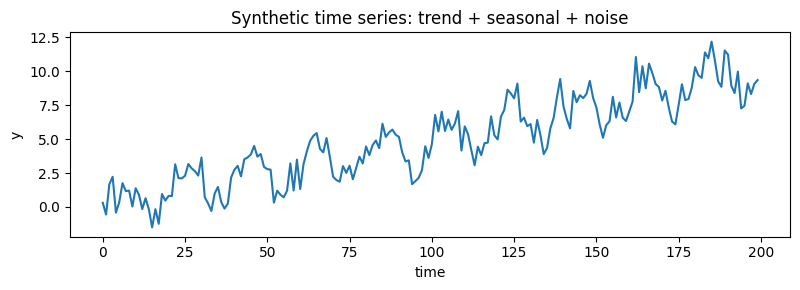

In [5]:
# Visualize the time series
plt.figure(figsize=(8, 3))
plt.plot(df["time"], df["y"], label="y (observed)")
plt.xlabel("time")
plt.ylabel("y")
plt.title("Synthetic time series: trend + seasonal + noise")
plt.tight_layout()
plt.show()

### From `y` to lag features with `pandas.shift`

We choose a number of lags, for example `L = 5` (look 5 steps into the past).

- `y_lag_1` = $y_{t-1}$
- `y_lag_2` = $y_{t-2}$
- ...
- `y_lag_5` = $y_{t-5}$

The first few rows will get `NaN` (there is no past yet); we drop those rows.

In [6]:
L = 5  # number of lags

df_lagged = df.copy()
for k in range(1, L + 1):
    df_lagged[f"y_lag_{k}"] = df_lagged["y"].shift(k)

# Drop rows with NaN (at the beginning)
df_lagged = df_lagged.dropna().reset_index(drop=True)

df_lagged.head()

,time,y,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5
0,5,0.347820,-0.419556,2.223189,1.673351,-0.557360,0.304717
1,6,1.759320,0.347820,-0.419556,2.223189,1.673351,-0.557360
2,7,1.166381,1.759320,0.347820,-0.419556,2.223189,1.673351
3,8,1.206098,1.166381,1.759320,0.347820,-0.419556,2.223189
4,9,0.029580,1.206098,1.166381,1.759320,0.347820,-0.419556


Now we can create a standard $(X, y)$ dataset:

- **Features X**: columns `y_lag_1` to `y_lag_L`.
- **Target y**: the current value `y`.

In [7]:
feature_cols = [f"y_lag_{k}" for k in range(1, L + 1)]
X = df_lagged[feature_cols].values
y_target = df_lagged["y"].values

X.shape, y_target.shape

((195, 5), (195,))

## 3. Adding an Exogenous Variable (Seasonal Effect)

Now we explicitly introduce an **exogenous variable** $z_t$ representing the seasonal pattern.

In our synthetic data, we **constructed** $y_t$ to depend on this seasonal pattern:

$$
y_t = \text{trend}_t + 0.7 \cdot z_t + \text{noise}_t,
$$

where

- $\text{trend}_t = 0.05 \cdot t$,
- $z_t = 2 \sin(2\pi t / 20)$.

So the exogenous variable $z_t$ actually has a genuine influence on $y_t$.

We now add $z_t$ as an extra feature in our supervised dataset. (In general it is advised to do this in a slightly different way with two variables, using $sin$ and $cos$, see the ``questions''.)

In [8]:
# Add the exogenous variable z to the original dataframe
df["z"] = seasonal  # same seasonal pattern we used to build y

# Build lagged features again, now keeping z at the "current" time
df_exog = df.copy()
for k in range(1, L + 1):
    df_exog[f"y_lag_{k}"] = df_exog["y"].shift(k)

# Drop rows with NaN
df_exog = df_exog.dropna().reset_index(drop=True)

feature_cols_exog = [f"y_lag_{k}" for k in range(1, L + 1)] + ["z"]
X_exog = df_exog[feature_cols_exog].values
y_exog_target = df_exog["y"].values

X_exog.shape, y_exog_target.shape

((195, 6), (195,))

In words:

- We predict $y_t$ based on:
  - lags of $y$: $y_{t-1}, \dots, y_{t-L}$;
  - the exogenous variable at the same time: $z_t$.

Because we constructed the data as
$y_t = \text{trend}_t + 0.7 z_t + \text{noise}_t$,
the model **can really use** `z` to improve predictions.

## 4. Temporal Train/Validation/Test Split

In standard (non–time series) supervised learning we usually do something like this:

- We **shuffle** the dataset so that the order of the samples is random.
- We then split into:
  - a **training set** (e.g. 60–80% of the data),
  - a **validation set** (for model selection and hyperparameter tuning),
  - a **test set** (for the final unbiased performance estimate).
- In scikit-learn this is often done with `train_test_split`, and for the validation set we might
  call it twice or use cross-validation.

This is fine because we assume that:
- the samples are **independent**, and  
- their order does **not** matter.

### Why this is a problem for time series

For time series, the order of the data **is essential**:

- $y_{t}$ is typically related to $y_{t-1}, y_{t-2}, \dots$
- In a real forecasting scenario, we always predict the **future** using only information from the **past**.

If we randomly shuffle a time series and then split, we get two big problems:

1. **Data leakage**  
   Future observations can end up in the training set, while earlier observations end up in
   the validation or test set.  
   The model then indirectly “sees the future” during training, which makes the performance
   look better than it will be in reality.

2. **Unrealistic evaluation**  
   In practice we will train on past data and make predictions on unseen future data.  
   A random split breaks this temporal structure and no longer mimics how the model will be used.

### How to split time series data instead

For time series, we should split **along the time axis**:

1. **Sort by time** (if not already sorted).
2. Choose one or two **cut points in time**:
   - Everything **before** the first cut → **training set**.
   - The period **between** the first and second cut → **validation set**.
   - The period **after** the second cut → **test set**.

For example (60/20/20 split in time order):

- Earliest 60% of the time points → train
- Next 20% → validation
- Last 20% → test

Important:

- We do **not shuffle** the data.
- Every observation in the validation and test sets occurs **later in time** than all observations in the training set.
- This way, the validation/test scenario matches the real forecasting scenario:  
  *“train on the past, predict the future”*.

In the next code cell, we implement exactly this idea by slicing the data by index instead of using `train_test_split` with shuffling.

In [9]:
n = len(df_exog)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

X_train = X_exog[:train_end]
y_train = y_exog_target[:train_end]

X_val = X_exog[train_end:val_end]
y_val = y_exog_target[train_end:val_end]

X_test = X_exog[val_end:]
y_test = y_exog_target[val_end:]

X_train.shape, X_val.shape, X_test.shape

((117, 6), (39, 6), (39, 6))

We now have:

- `X_train, y_train` : earliest period
- `X_val, y_val`     : middle period
- `X_test, y_test`   : latest period

This is conceptually different from the classic random splits:

- We **do not shuffle**.
- The index (time) determines the split.

After this, you can use any regression model from scikit-learn
(`LinearRegression`, `RandomForestRegressor`, etc.).  


## 5. Cross-Validation for Time Series

In standard supervised learning we often use **k-fold cross-validation**:

- Randomly split the data into $k$ folds.
- Train on $k-1$ folds, validate on the remaining fold.
- Shuffle the data so each fold is a mix of all time periods.

For time series this is **not appropriate**, because shuffling destroys the time structure
and can cause **look-ahead bias**: the model might indirectly see “future” data in training.

### 5.1. Idea: time-aware cross-validation (rolling / expanding window)

For time series, cross-validation should respect the time order. Typical patterns:

- **Expanding window**:
  - Fold 1: train on [1 … $t_1$], validate on ($t_1+1$ … $t_2$]
  - Fold 2: train on [1 … $t_2$], validate on ($t_2+1$ … $t_3$]
  - etc.
- **Sliding window** (fixed-size training window):
  - Fold 1: train on [1 … $t_1$], validate on ($t_1+1$ … $t_2$]
  - Fold 2: train on ($t_{\text{start2}}$ … $t_2$], validate on ($t_2+1$ … $t_3$]
  - Training window moves forward in time.

The key rule: **training data must always be earlier than validation data**.

### 5.2. Using `TimeSeriesSplit` in scikit-learn

scikit-learn provides `TimeSeriesSplit` to implement time-aware splits.
It behaves like an expanding window (by default).
Here is a small example using our `X_exog, y_exog_target`:

In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)   #tscv = time series cross validation

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_exog), start=1):
    print(f"Fold {fold}")
    print(f"  Train indices: {train_idx[0]} .. {train_idx[-1]}")
    print(f"  Val   indices: {val_idx[0]} .. {val_idx[-1]}")

Fold 1
  Train indices: 0 .. 38
  Val   indices: 39 .. 77
Fold 2
  Train indices: 0 .. 77
  Val   indices: 78 .. 116
Fold 3
  Train indices: 0 .. 116
  Val   indices: 117 .. 155
Fold 4
  Train indices: 0 .. 155
  Val   indices: 156 .. 194


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

tscv = TimeSeriesSplit(n_splits=4)
rmse_per_fold = []

for train_idx, val_idx in tscv.split(X_exog):
    X_tr, X_val_cv = X_exog[train_idx], X_exog[val_idx]
    y_tr, y_val_cv = y_exog_target[train_idx], y_exog_target[val_idx]
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val_cv)
    rmse = root_mean_squared_error(y_val_cv, y_pred)
    rmse_per_fold.append(rmse)

rmse_per_fold

[1.29479204100253, 1.2597293393057685, 1.2999824173371397, 1.3842573524522381]


## 6. End-to-End Example: Train, Validate, Test a Model

Now we use the temporally split data (`X_train`, `X_val`, `X_test`) to:

1. Train a simple model on the **training set**.
2. Evaluate it on the **validation set**.
3. Refit on **train + validation**.
4. Evaluate the final model on the **test set**.

We will use a `LinearRegression` model.  
Because we constructed the data as

$$
y_t = \text{trend}_t + 0.7 z_t + \text{noise}_t,
$$

we expect that:

- lagged values of $y$ help capture the underlying trend,
- the exogenous variable $z_t$ helps capture the seasonal pattern.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# 1. Train on TRAIN set
# ---------------------------------------------------------
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# ---------------------------------------------------------
# 2. Validate on VALIDATION set
# ---------------------------------------------------------
y_val_pred = linreg.predict(X_val)
rmse_val = root_mean_squared_error(y_val, y_val_pred)

rmse_val

1.2999824173371397

In [13]:
# ---------------------------------------------------------
# 3. Refit on TRAIN + VALIDATION
# ---------------------------------------------------------
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

final_model = LinearRegression()
final_model.fit(X_train_val, y_train_val)

# ---------------------------------------------------------
# 4. Evaluate on TEST set
# ---------------------------------------------------------
y_test_pred = final_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

rmse_test

1.3842573524522384

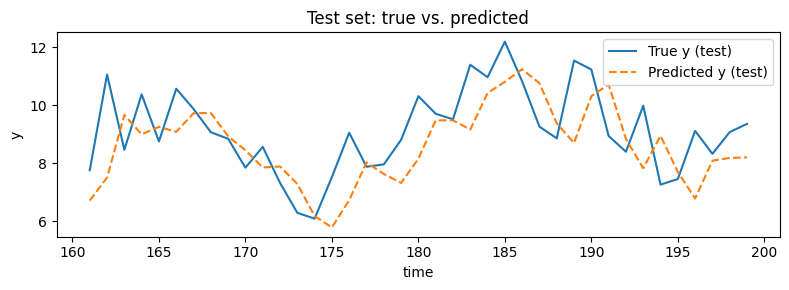

In [14]:
# Optional: visualize true vs. predicted on the test period
test_time = df_exog["time"].iloc[val_end:]  # corresponding time indices for test set

plt.figure(figsize=(8, 3))
plt.plot(test_time, y_test, label="True y (test)")
plt.plot(test_time, y_test_pred, label="Predicted y (test)", linestyle="--")
plt.xlabel("time")
plt.ylabel("y")
plt.title("Test set: true vs. predicted")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Comparing with a Naive Baseline ($\hat y_t = y_{t-1}$)

To understand whether our model is actually useful, we should compare it to a very simple
**naive baseline**.

A common baseline for time series is:

$$
\hat y_t = y_{t-1},
$$

i.e. “tomorrow will be the same as today”.

In our lagged dataset `df_exog`, we already have a column `y_lag_1` which is exactly $y_{t-1}$.
So on the test period we can use:

- **Baseline prediction**: `y_lag_1`  
- **True target**: `y`  

and compute the RMSE of this naive model, then compare it to the RMSE of our linear regression
model on the same test set.